In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('EURUSD_M15_20241030.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
#     np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
# )

df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 53.98
Test Accuracy: 53.40
Total Accuracy: 53.87


In [ ]:
A_wlr_th = 0.977
A_raw_accuracy_th = 53.5
A_filtered_accuracy_th = 54.5
A_sharp_ratio_th = 9
A_max_dd_th = 0.04
A_position_count_th = 22244
A_cumulative_th = 2.75
A_annual_th = 1.16

In [ ]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': A_wlr_th,
    'raw_accuracy': A_raw_accuracy_th,
    'filtered_accuracy': A_filtered_accuracy_th,
    'sharp_ratio': A_sharp_ratio_th,
    'max_dd': A_max_dd_th,
    'position_count': A_position_count_th,
    'cumulative': A_cumulative_th,
    'annual' : A_annual_th}
joblib.dump(objects_to_save, 'U_A.joblib')

['U_A.joblib']

# Filter and Evaluations

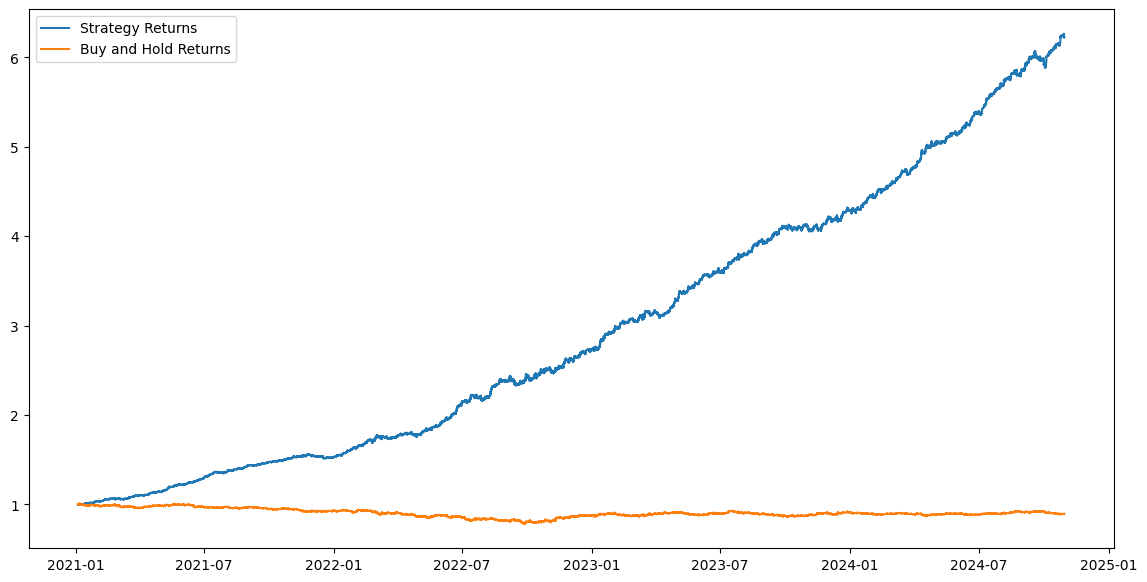

In [6]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [7]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.49
Annualized Sharpe Ratio: 6.25
Maximum Drawdown: -0.05


In [8]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    47227
1    46114
Name: count, dtype: int64
pred
 1    52508
-1    40833
Name: count, dtype: int64
position
 0.0    43747
 1.0    25117
-1.0    24477
Name: count, dtype: int64


In [9]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.96469967)

In [10]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,...,9.334100e+04,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,42224.000000,49645.000000,93341.000000
mean,1.101814,1.102150,1.101476,1.101814,-0.000001,0.494038,-0.000001,0.906150,0.000394,-0.000099,...,2.745608e-01,0.125079,0.500056,0.499944,0.519035,0.000020,2.947222,0.000323,0.000311,0.020471
std,0.058821,0.058767,0.058870,0.058819,0.000498,0.499967,0.000496,0.046254,0.000305,1.031029,...,4.207916e-01,0.992152,0.028781,0.028781,0.021587,0.000496,1.515776,0.000413,0.000363,0.043963
min,0.953840,0.955100,0.953490,0.953830,-0.011372,0.000000,-0.011372,0.784125,0.000014,-4.022394,...,0.000000e+00,-1.000000,0.184982,0.262266,0.500000,-0.016178,0.995012,0.000008,0.000008,-0.018296
25%,1.069340,1.069650,1.069030,1.069340,-0.000203,0.000000,-0.000199,0.881564,0.000201,-0.690714,...,8.797084e-08,-1.000000,0.483009,0.487032,0.507789,-0.000174,1.540352,0.000089,0.000092,-0.002434
50%,1.089300,1.089580,1.089030,1.089300,0.000008,0.000000,0.000000,0.899097,0.000313,0.020215,...,2.556249e-04,1.000000,0.497436,0.502564,0.514876,0.000027,2.602090,0.000202,0.000206,0.012001
75%,1.133950,1.134290,1.133640,1.133950,0.000203,1.000000,0.000200,0.928670,0.000487,0.692846,...,7.586022e-01,1.000000,0.512968,0.516991,0.521747,0.000224,4.110326,0.000414,0.000398,0.025994
max,1.234590,1.234860,1.234240,1.234590,0.016178,1.000000,0.016178,1.009437,0.005690,4.669246,...,9.999373e-01,1.000000,0.737734,0.815018,0.815018,0.009177,6.263568,0.016178,0.009177,0.623266


In [11]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [12]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:15:00,1.22553,1.22654,1.22534,1.22622,0.000539,1,0.000212,1.002790,0.000475,1.134225,...,0.999759,-1,0.517897,0.482103,0.517897,-0.000212,0.999453,0.000212,NaN,0.018152
2021-01-04 09:30:00,1.22622,1.22676,1.22593,1.22648,0.000212,1,0.000122,1.002913,0.000456,0.464534,...,0.999791,-1,0.511566,0.488434,0.511566,-0.000122,0.999331,0.000122,NaN,0.005258
2021-01-04 09:45:00,1.22645,1.22672,1.22628,1.22663,0.000122,0,-0.000261,1.002651,0.000457,0.267693,...,0.999430,-1,0.506422,0.493578,0.506422,0.000261,0.999592,NaN,0.000261,-0.005216
2021-01-04 10:15:00,1.22627,1.22702,1.22610,1.22681,0.000408,1,0.000277,1.003338,0.000281,1.453149,...,0.181986,-1,0.526371,0.473629,0.526371,-0.000277,0.999722,0.000277,NaN,0.035411
2021-01-04 10:30:00,1.22681,1.22735,1.22650,1.22715,0.000277,1,0.001068,1.004410,0.000255,1.085242,...,0.162085,-1,0.514864,0.485136,0.514864,-0.001068,0.998656,0.001068,NaN,0.011975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 13:30:00,1.08000,1.08001,1.07958,1.07974,-0.000231,1,0.000120,0.893188,0.000205,-1.130393,...,0.000072,1,0.489128,0.510872,0.510872,0.000120,6.247313,NaN,0.000120,0.003847
2024-10-29 14:30:00,1.07979,1.07985,1.07873,1.07874,-0.000982,0,-0.001010,0.891353,0.000347,-2.825789,...,0.872812,1,0.468350,0.531650,0.531650,-0.001010,6.247539,0.001010,NaN,0.046161
2024-10-29 14:45:00,1.07874,1.07879,1.07759,1.07765,-0.001010,1,0.000019,0.891369,0.000436,-2.318569,...,0.997638,1,0.469109,0.530891,0.530891,0.000019,6.247654,NaN,0.000019,0.044617


In [13]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

54.915204463695765

In [14]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    13917
1    13325
Name: count, dtype: int64
pred
1    15303
0    11939
Name: count, dtype: int64
position
 1.0    15303
-1.0    11939
Name: count, dtype: int64


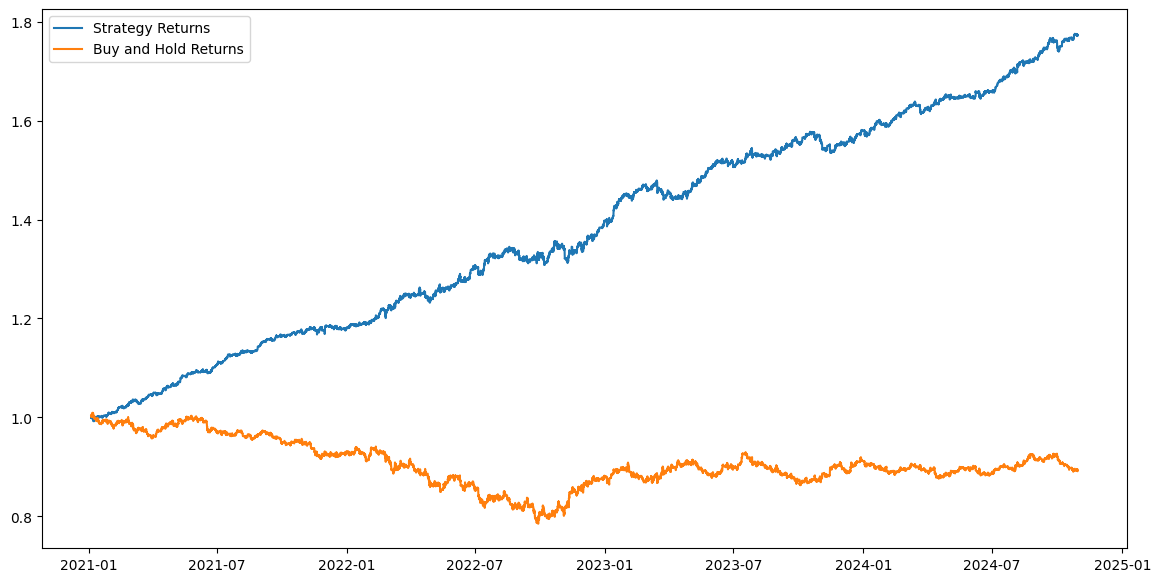

In [15]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [16]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.52
Annualized Sharpe Ratio: 6.26
Maximum Drawdown: -0.03


In [17]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.92319554)

In [18]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,...,2.724200e+04,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,12058.000000,14771.000000,27242.000000
mean,1.101325,1.101703,1.100927,1.101310,-0.000014,0.489134,-0.000002,0.905712,0.000426,-0.025809,...,2.956143e-01,0.123486,0.499602,0.500398,0.519276,0.000021,1.375254,0.000362,0.000335,-0.001442
std,0.058883,0.058818,0.058942,0.058881,0.000594,0.499891,0.000531,0.046318,0.000330,1.176852,...,4.283309e-01,0.992365,0.028400,0.028400,0.020860,0.000530,0.216009,0.000443,0.000374,0.043454
min,0.954980,0.955100,0.954130,0.954780,-0.010313,0.000000,-0.010313,0.784903,0.000023,-4.022394,...,0.000000e+00,-1.000000,0.190683,0.272436,0.500000,-0.010313,0.992321,0.000008,0.000008,-0.041597
25%,1.069043,1.069412,1.068560,1.068990,-0.000265,0.000000,-0.000223,0.881298,0.000220,-0.816256,...,5.564602e-07,-1.000000,0.481147,0.485933,0.508499,-0.000190,1.182379,0.000100,0.000101,-0.023891
50%,1.089080,1.089395,1.088730,1.089080,-0.000009,0.000000,0.000000,0.898835,0.000341,-0.045584,...,5.651298e-04,1.000000,0.497316,0.502684,0.516134,0.000036,1.346936,0.000230,0.000225,-0.007986
75%,1.133227,1.133550,1.132918,1.133288,0.000241,1.000000,0.000220,0.928116,0.000526,0.760460,...,8.687102e-01,1.000000,0.514067,0.518853,0.522469,0.000250,1.556644,0.000468,0.000434,0.005210
max,1.233750,1.234600,1.233620,1.234590,0.009177,1.000000,0.008288,1.009437,0.005595,4.669246,...,9.999352e-01,1.000000,0.727564,0.809317,0.809317,0.008288,1.775665,0.010313,0.008288,0.602771


In [19]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 05:15:00,1.22531,1.22545,1.22494,1.22533,0.000016,1,0.000269,1.002119,0.000253,0.064639,...,0.000000e+00,1,0.277531,0.722469,0.722469,0.000269,1.000269,NaN,0.000269,0.434782
2021-01-04 05:30:00,1.22531,1.22568,1.22520,1.22566,0.000269,0,-0.000261,1.001857,0.000226,1.189849,...,1.086452e-06,-1,0.524425,0.475575,0.524425,0.000261,1.000531,NaN,0.000261,0.031448
2021-01-04 05:45:00,1.22566,1.22567,1.22478,1.22534,-0.000261,1,0.000065,1.001923,0.000218,-1.198056,...,1.041121e-06,1,0.479709,0.520291,0.520291,0.000065,1.000596,NaN,0.000065,0.023028
2021-01-04 06:00:00,1.22534,1.22569,1.22509,1.22542,0.000065,0,-0.000294,1.001628,0.000211,0.309408,...,8.782547e-07,1,0.464823,0.535177,0.535177,-0.000294,1.000302,0.000294,NaN,0.053345
2021-01-04 06:15:00,1.22542,1.22542,1.22502,1.22506,-0.000294,0,-0.000204,1.001424,0.000208,-1.412505,...,7.620709e-07,1,0.482038,0.517962,0.517962,-0.000204,1.000098,0.000204,NaN,0.018286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 22:30:00,1.08147,1.08161,1.08141,1.08141,-0.000074,1,0.000240,0.894681,0.000221,-0.334087,...,7.246228e-06,1,0.492280,0.507720,0.507720,0.000240,6.228453,NaN,0.000240,-0.002574
2024-10-29 22:45:00,1.08141,1.08170,1.08141,1.08167,0.000240,0,0.000000,0.894681,0.000164,1.465203,...,4.551263e-07,-1,0.524786,0.475214,0.524786,-0.000000,6.228453,NaN,NaN,0.032184
2024-10-29 23:30:00,1.08135,1.08152,1.08121,1.08149,-0.000166,1,0.000009,0.894541,0.000133,-1.252160,...,4.914013e-09,1,0.499572,0.500428,0.500428,0.000009,6.228511,NaN,0.000009,-0.017425


In [20]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy


# df_filtered_2 = df[((df['position'] == 1) & (df['kelly'] > 0)) | ((df['position'] == -1) & (df['kelly'] > 0))].copy()
# df_filtered_2['position'] = df_filtered_2['position'].map({-1: 0, 1: 1})
# accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.position) * 100
# accuracy

59.068062827225134

In [21]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 10:15:00,1.22627,1.22702,1.22610,1.22681,0.000408,1,0.000277,1.003338,0.000281,1.453149,...,0.181986,0,0.526371,0.473629,0.526371,-0.000277,0.999649,0.000277,NaN,0.013338
2021-01-04 10:45:00,1.22715,1.22855,1.22704,1.22846,0.001068,0,-0.000334,1.004075,0.000380,2.808545,...,0.980121,0,0.523592,0.476408,0.523592,0.000334,0.998916,NaN,0.000334,0.007549
2021-01-04 14:30:00,1.22936,1.22992,1.22908,1.22985,0.000415,0,-0.000342,1.005204,0.000221,1.877545,...,0.000419,0,0.524778,0.475222,0.524778,0.000342,0.999355,NaN,0.000342,0.010020
2021-01-04 17:15:00,1.22884,1.22900,1.22724,1.22783,-0.000814,0,-0.000635,1.003260,0.000673,-1.209725,...,0.943319,1,0.478906,0.521094,0.521094,-0.000635,0.999906,0.000635,NaN,0.002346
2021-01-04 17:30:00,1.22783,1.22814,1.22705,1.22705,-0.000635,0,-0.000016,1.003244,0.000679,-0.935986,...,0.959049,1,0.479761,0.520239,0.520239,-0.000016,0.999890,0.000016,NaN,0.000564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 11:15:00,1.08177,1.08240,1.08176,1.08213,0.000324,1,0.000203,0.895239,0.000270,1.196766,...,0.000182,0,0.528498,0.471502,0.528498,-0.000203,1.773380,0.000203,NaN,0.017770
2024-10-29 11:30:00,1.08214,1.08238,1.08202,1.08235,0.000203,0,-0.000111,0.895140,0.000269,0.757078,...,0.000139,0,0.527828,0.472172,0.527828,0.000111,1.773577,NaN,0.000111,0.016375
2024-10-29 13:15:00,1.08049,1.08050,1.07997,1.07999,-0.000463,0,-0.000231,0.893081,0.000273,-1.697774,...,0.000281,1,0.479107,0.520893,0.520893,-0.000231,1.773166,0.000231,NaN,0.001926


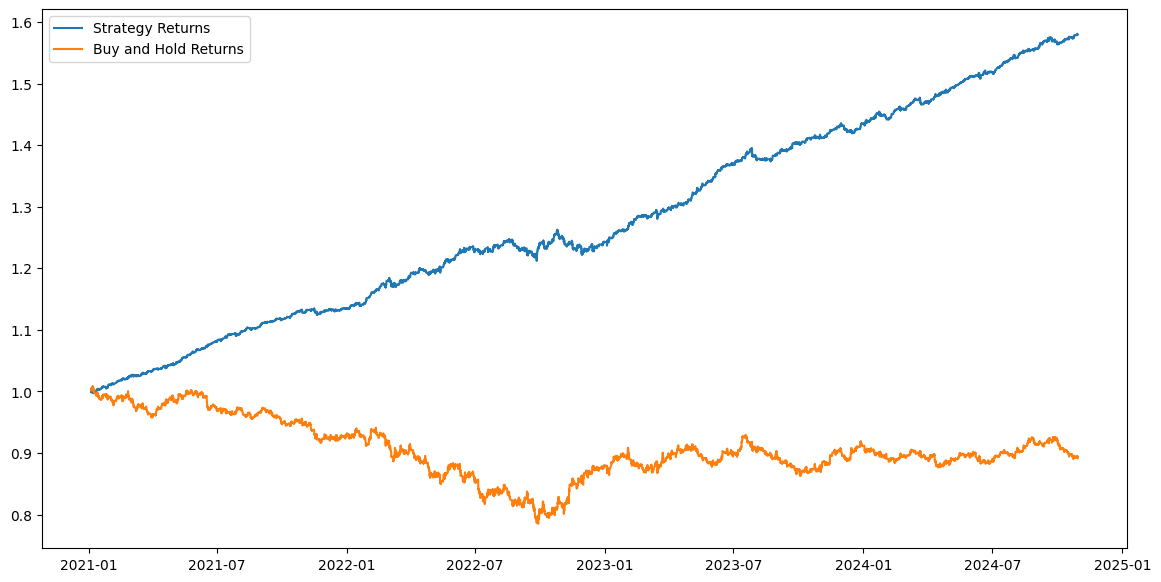

In [22]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [23]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.8972531)

In [24]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 1.19
Annualized Sharpe Ratio: 13.28
Maximum Drawdown: -0.03
